# Notebook 01: What is a seismogram?

**Goal (about 1 hour):** read a seismogram with ObsPy, understand what the numbers are, and plot one earthquake on three channels.

No seismology background is assumed. If you know what a sampled time series is, you know what a seismogram is: ground velocity at one point, sampled 100 times a second, on three perpendicular axes.

This lesson leans on two existing tutorials rather than repeating them; open them in another tab:

- ObsPy's [Reading Seismograms](https://docs.obspy.org/tutorial/code_snippets/reading_seismograms.html) and [UTCDateTime](https://docs.obspy.org/tutorial/code_snippets/utc_date_time.html) pages (ObsPy Development Team, LGPL v3; Beyreuther et al., 2010).
- Seismo-Live's [03 waveform data](https://seismo-live.github.io/html/ObsPy/03_waveform_data_wrapper.html) notebook (Lion Krischer, CC BY-NC-SA 4.0).

In [1]:
# --- setup: make the repo importable and keep figures inline ---
import sys, warnings
from pathlib import Path
REPO = Path.cwd().parent if (Path.cwd() / "../rainier_sws").exists() else Path.cwd()
sys.path.insert(0, str(REPO))
warnings.filterwarnings("ignore")
%matplotlib inline
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
from rainier_sws import paths, data, measure, quality, stats
print("repo:", REPO)

repo: /home/claude/rainier-sws-tutorials


## 1. A seismometer in one paragraph

A seismometer is a mass on a spring with a coil and a magnet; when the ground moves, the mass lags and the coil produces a voltage proportional to ground **velocity**. A digitizer samples that voltage (here at 100 Hz) and the result is streamed to a data center. Three sensors at right angles give three channels: **Z** (up), **N** (north), **E** (east). The IRIS/EarthScope education catalog has good animations if you want to see one move: [iris.edu/hq/inclass](https://www.iris.edu/hq/inclass/) (CC BY 4.0).

Each channel has a 3-letter code. For station STAR it is `EHZ`, `EHN`, `EHE`: `E` = short-period instrument sampled at 100 Hz, `H` = high-gain seismometer, and the last letter is the orientation.

## 2. Reading a miniSEED file

MiniSEED is the standard compressed format for seismic data. ObsPy's `read()` returns a **Stream** (a list of **Trace**s). A Trace is a numpy array (`.data`) plus metadata (`.stats`).

In [2]:
import obspy
files = sorted(paths.station_waveform_dir("STAR").glob("*.mseed"))
st = obspy.read(str(files[0]))
print(st.__class__.__name__, "with", len(st), "traces; first three:")
print(st[:3])

Stream with 300 traces; first three:
3 Trace(s) in Stream:
UW.STAR.01.EHE | 2025-07-08T05:13:56.960000Z - 2025-07-08T05:14:16.960000Z | 100.0 Hz, 2001 samples
UW.STAR.01.EHE | 2025-07-08T08:40:16.080000Z - 2025-07-08T08:40:36.070000Z | 100.0 Hz, 2000 samples
UW.STAR.01.EHE | 2025-07-08T08:39:45.010000Z - 2025-07-08T08:40:05.000000Z | 100.0 Hz, 2000 samples


In [3]:
tr = st[0]
print(tr.stats)                    # metadata
print(type(tr.data), tr.data.dtype, tr.data.shape, "samples")
print("first 10 samples (digitizer counts):", tr.data[:10])

         network: UW
         station: STAR
        location: 01
         channel: EHE
       starttime: 2025-07-08T05:13:56.960000Z
         endtime: 2025-07-08T05:14:16.960000Z
   sampling_rate: 100.0
           delta: 0.01
            npts: 2001
           calib: 1.0
         _format: MSEED
           mseed: AttribDict({'dataquality': 'M', 'number_of_records': 5, 'encoding': 'STEIM2', 'byteorder': '>', 'record_length': 512, 'filesize': 822272})
<class 'numpy.ndarray'> int32 (2001,) samples
first 10 samples (digitizer counts): [16 21 15  0  4  9  9 10 21 14]


Things to notice:

- `sampling_rate` is 100 Hz, so `delta` (the sample interval) is 0.01 s and 2001 samples is 20 s.
- `starttime` is an ObsPy `UTCDateTime`. Everything in seismology is UTC; you never use local time.
- The data are integer **counts** from the digitizer, not m/s. Converting to physical units needs the instrument response; for splitting we only need relative amplitudes on the two horizontals, so we skip that.

## 3. Time, the ObsPy way

`UTCDateTime` supports arithmetic in seconds. This is used everywhere in the lessons, so try a few things.

In [4]:
from obspy import UTCDateTime
t = tr.stats.starttime
print(t, "|", t + 5, "|", t.julday, "| epoch", t.timestamp)
print("length of trace in seconds:", tr.stats.endtime - tr.stats.starttime)

2025-07-08T05:13:56.960000Z | 2025-07-08T05:14:01.960000Z | 189 | epoch 1751951636.96
length of trace in seconds: 20.0


## 4. One earthquake, three channels

The cache stores many earthquakes per file. The helper `data.get_event_stream` picks out one earthquake (one row of the catalog) and returns exactly Z, N, E. We use the catalog of earthquakes recorded at STAR, which you will meet properly in notebook 03.

In [5]:
cat = data.load_station_catalog("STAR")
row = cat[cat.evid == 61504668].iloc[0]       # the event used in Michael's figure 3
ev = data.get_event_stream("STAR", row, allow_download=False)
print("data came from:", ev.source)
ev

data came from: cache


3 Trace(s) in Stream:
UW.STAR.01.EHZ | 2025-07-18T14:09:59.070000Z - 2025-07-18T14:10:19.060000Z | 100.0 Hz, 2000 samples
UW.STAR.01.EHN | 2025-07-18T14:09:59.070000Z - 2025-07-18T14:10:19.060000Z | 100.0 Hz, 2000 samples
UW.STAR.01.EHE | 2025-07-18T14:09:59.070000Z - 2025-07-18T14:10:19.060000Z | 100.0 Hz, 2000 samples

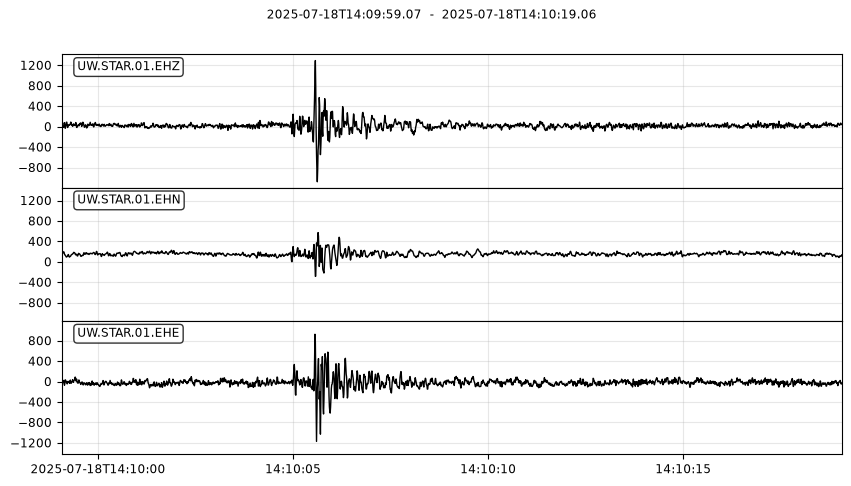

In [6]:
ev.plot(size=(900, 500));   # ObsPy's quick-look plot

ObsPy's built-in plot is fine for a quick look. For anything you will show someone else, draw it yourself so you control the axes. Here is the same event with time relative to the earthquake's origin time and the analyst's P and S picks marked.

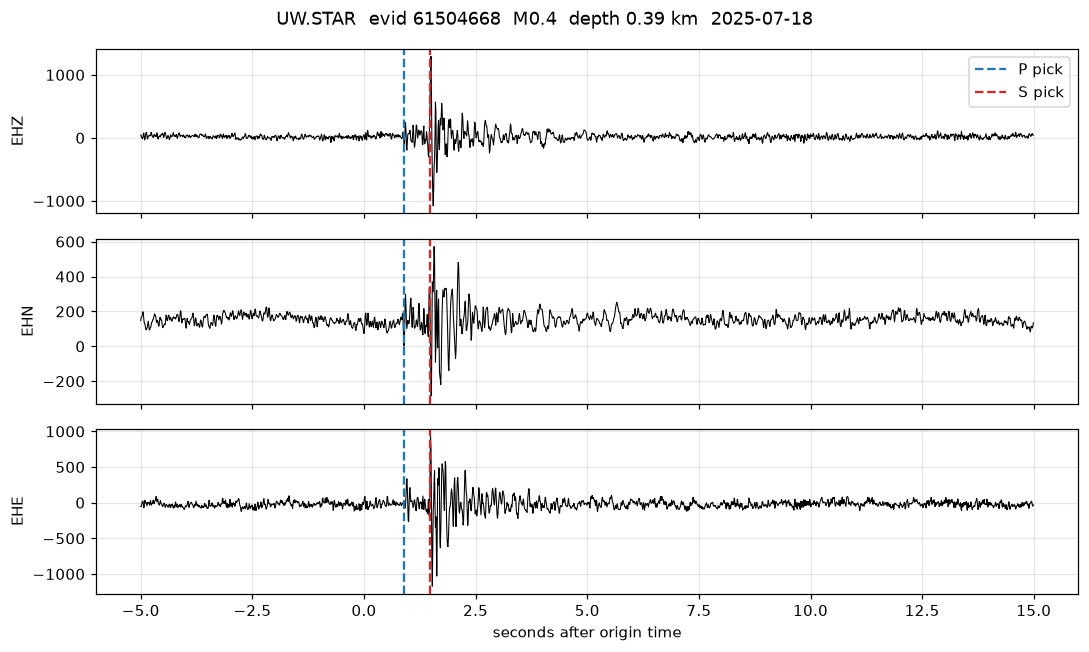

In [7]:
origin = data.to_utc(row.origin_time)
p_rel, s_rel = data.to_utc(row.p_time) - origin, data.to_utc(row.s_time) - origin

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
for ax, tr in zip(axes, ev):
    t_rel = tr.times(reftime=origin)
    ax.plot(t_rel, tr.data, "k", lw=0.7)
    ax.axvline(p_rel, color="tab:blue", ls="--", label="P pick")
    ax.axvline(s_rel, color="tab:red", ls="--", label="S pick")
    ax.set_ylabel(tr.stats.channel)
axes[0].legend(loc="upper right"); axes[-1].set_xlabel("seconds after origin time")
fig.suptitle(f"UW.STAR  evid {row.evid}  M{row.event_magnitude}  depth {row.event_depth} km  {origin.date}")
plt.tight_layout()

## 5. Read the picture

- Before the P pick: background noise.
- At the **P** pick: a small, sharp, high-frequency onset. The P wave is a compressional wave and shows most on **Z** for a steep arrival.
- At the **S** pick (about 0.6 s later here): a larger, lower-frequency onset, strongest on the **horizontal** channels. S waves shake the ground sideways; they carry the splitting signal.
- After S: the coda, scattered energy that decays for seconds.

The S-minus-P time is a ruler: with Vp around 5 km/s and Vs around 3 km/s, each second of S-P is roughly 8 km of distance (the classic rule of thumb is distance in km approx 8 times S-P in seconds). A 0.6 s S-P means this earthquake is only a few km from the station.

In [8]:
print(f"S - P = {s_rel - p_rel:.2f} s  ->  roughly {8 * (s_rel - p_rel):.1f} km from the station")

S - P = 0.59 s  ->  roughly 4.7 km from the station


## 6. Exercises

1. Plot three other events from `cat` (pick rows at random). Do they all look like this one? Which ones would you not trust?
2. Change the plot to show only 1 s before P to 2 s after S. What does the S onset look like on N versus E?
3. Using `tr.stats`, confirm by arithmetic that `npts`, `delta` and `endtime - starttime` agree.
4. (Stretch) Read the ObsPy [Reading Seismograms](https://docs.obspy.org/tutorial/code_snippets/reading_seismograms.html) page and try `st.merge()` and `tr.slice()`.

Write what surprised you in your lab notebook. Next: `02_getting_data_from_earthscope.ipynb`.